In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [45]:
file_path = '/content/drive/MyDrive/datasets/ADANIPORTS.csv'

In [3]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow keras

# Preprocessing


In [46]:
#preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

def load_and_preprocess_data(file_path, sequence_length=60):
    data = pd.read_csv(file_path)
    data = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
    data['Date'] = pd.to_datetime(data['Date'])
    data.dropna(inplace=True)
    data.sort_values('Date', inplace=True)

    feature_cols = ['Open','High','Low','Close','Volume']
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaled_X = scaler_X.fit_transform(data[feature_cols])
    scaled_y = scaler_y.fit_transform(data[['Close']])

    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(scaled_X[i-sequence_length:i])
        y.append(scaled_y[i])
    X, y = np.array(X), np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test, scaler_X, scaler_y, data


# exploration

In [47]:
#exploration
import matplotlib.pyplot as plt

def explore_data(data):
    print("\n Columns in dataset:")
    print(data.columns)
    print("\n Basic Statistics:")
    print(data.describe())

    plt.figure(figsize=(10, 5))
    plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')
    plt.title('Stock Closing Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

# training

In [56]:
#training
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Dropout(0.2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    model.summary()
    return model

def train_model(model, X_train, y_train, X_test, y_test, epochs=30, batch_size=32):
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                        epochs=epochs, batch_size=batch_size, verbose=1)
    return model, history

# evaluation

In [57]:
#evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model(model, X_test, y_test, scaler_y):
    # Predict
    predictions = model.predict(X_test)
    predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1))
    y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    # Metrics
    mse = mean_squared_error(y_test_actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, predictions)
    r2 = r2_score(y_test_actual, predictions)

    print("\n Model Evaluation Results:")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

    return predictions, y_test_actual, mse, rmse, mae, r2


In [61]:
def visualize_results(y_true, y_pred):
    plt.figure(figsize=(10,5))
    plt.plot(y_true, label='Actual Price', color='blue')
    plt.plot(y_pred, label='Predicted Price', color='red')
    plt.title('Actual vs Predicted Stock Prices')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Main

X_train shape: (2609, 60, 5)

 Columns in dataset:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

 Basic Statistics:
                                Date         Open         High          Low  \
count                           3322  3322.000000  3322.000000  3322.000000   
mean   2014-08-14 03:47:08.416616448   344.763019   351.608007   337.531969   
min              2007-11-27 00:00:00   108.000000   110.450000   105.650000   
25%              2011-04-07 06:00:00   164.850000   168.000000   161.600000   
50%              2014-08-06 12:00:00   325.750000   331.275000   319.850000   
75%              2017-12-18 18:00:00   401.000000   407.187500   395.000000   
max              2021-04-30 00:00:00  1310.250000  1324.000000  1270.000000   
std                              NaN   193.619992   198.617808   188.676614   

             Close        Volume  
count  3322.000000  3.322000e+03  
mean    344.201626  2.954564e+06  
min     108.000000  1.236600e+04  
25%

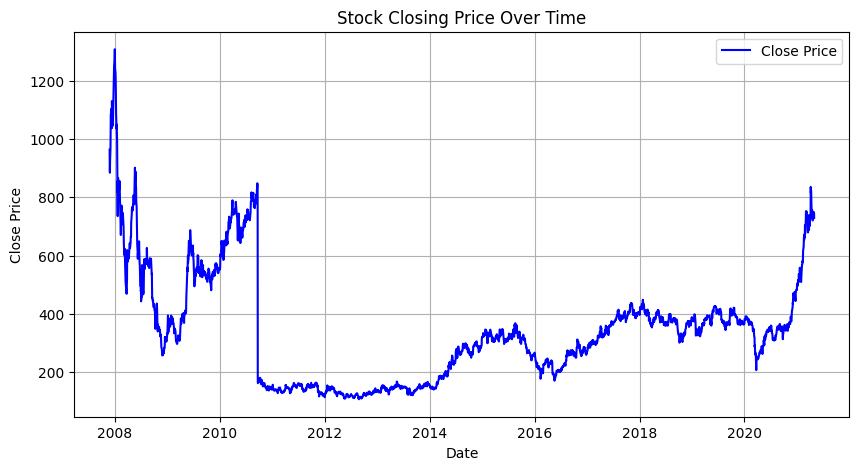

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_32 (Conv1D)              │ (None, 58, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │       106,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,353 (517.00 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0093 - mae: 0.0516 - val_loss: 0.0023 - val_mae: 0.0389
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018 - mae: 0.0243 - val_loss: 0.0048 - val_mae: 0.0613
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - mae: 0.0234 - val_loss: 0.0031 - val_mae: 0.0457
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011 - mae: 0.0199 - val_loss: 0.0020 - val_mae: 0.0328
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - mae: 0.0196 - val_loss: 0.0031 - val_mae: 0.0444
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.9456e-04 - mae: 0.0176 - val_loss: 0.0014 - val_mae: 0.0248
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.9955e-04 - mae: 0.0175 - val_loss: 0.0021 - val_mae: 0.0335
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0011 - mae: 0.0192 - val_loss: 0.0021 - val_mae: 0.0324
Epoch 9/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - los

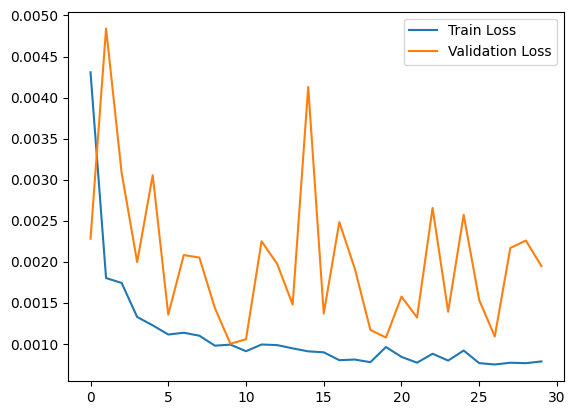

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

 Model Evaluation Results:
MSE  : 2803.8080
RMSE : 52.9510
MAE  : 35.4018
R²   : 0.7630


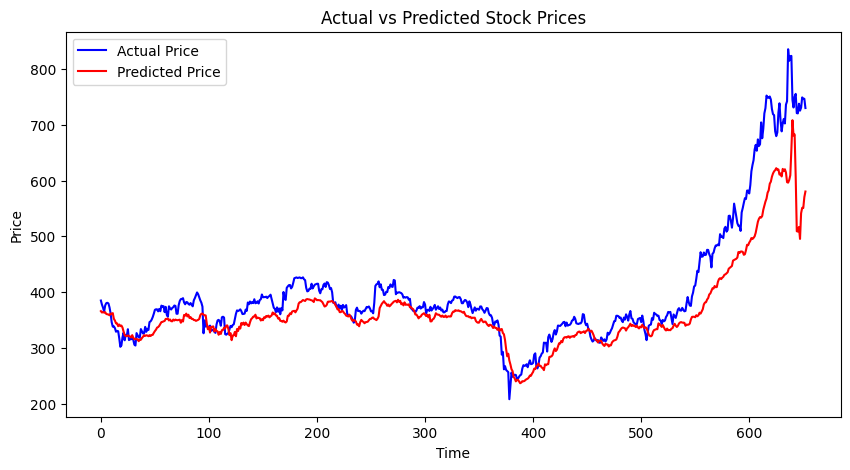

In [63]:
#main
# Parameters
sequence_length = 60
file_path = '/content/drive/MyDrive/DataSets/ADANIPORTS.csv'

# Load & preprocess
X_train, X_test, y_train, y_test, scaler_X, scaler_y, data = load_and_preprocess_data(file_path, sequence_length)
print("X_train shape:", X_train.shape)

# Explore
explore_data(data)

# Build & train
model = build_cnn_model((X_train.shape[1], X_train.shape[2]))
model, history = train_model(model, X_train, y_train, X_test, y_test)

# show training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(); plt.show()

# Evaluate
y_pred, y_true, mse, rmse, mae, r2 = evaluate_model(model, X_test, y_test, scaler_y)
visualize_results(y_true, y_pred)
